In [1]:
import sqlite3
import pandas as pd

In [2]:
conn = sqlite3.connect('movie.db') 
cursor = conn.cursor()

# Mevcut tabloları listele
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

if not tables:
    print("HATA: Bağlandığınız veritabanı dosyası boş! Dosya yolunu kontrol edin.")
else:
    print("Bağlanılan dosyada bulunan tablolar:", tables)
    print("\n--- imdb250 Tablosundaki İlk 5 Satır ---")
    try:
        cursor.execute("SELECT * FROM ImdbTop250 LIMIT 5")
        rows = cursor.fetchall()
        
        for row in rows:
            print(row)
    except sqlite3.OperationalError:
        print("HATA: 'imdb250' adında bir tablo bulunamadı. Lütfen tablo adını kontrol edin.")

conn.close()

Bağlanılan dosyada bulunan tablolar: [('ImdbTop250',)]

--- imdb250 Tablosundaki İlk 5 Satır ---
(1, 'The Shawshank Redemption', 'Dram', 9.3, 1994)
(2, 'The Godfather', 'Suç-Dram', 9.2, 1972)
(3, 'The Dark Knight', 'Aksiyon-Suç-Dram', 9, 2008)
(4, 'The Godfather Part II', 'Suç-Dram', 9, 1974)
(5, '12 Angry Men', 'Suç-Dram', 9, 1957)


In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. VERİ TOPLAMA 
# Veritabanına bağlanıp verileri DataFrame'e aktarıyoruz 
conn = sqlite3.connect('movie.db')
query = "SELECT * FROM ImdbTop250"
df = pd.read_sql_query(query, conn)
conn.close()

# 2. VERİ HAZIRLAMA VE TEMİZLEME 
# Eksik veri kontrolü 
print("Eksik Veri Sayısı:\n", df.isnull().sum())

# Kategori sütunundaki 'Suç-Dram' gibi birleşik yapıları ayıklayarak sadece ilk kategoriyi alıyoruz
df['Ana_Kategori'] = df['Kategori'].apply(lambda x: x.split('-')[0])

# 3. ÖZELLİK MÜHENDİSLİĞİ  
# 'Yil' bilgisinden filmin yaşını hesaplıyoruz
df['Film_Yasi'] = 2026 - df['Yil']

# Filmleri yıllarına göre dönemlere ayırıyoruz (Örn: 2000 öncesi ve sonrası) 
df['Donem'] = df['Yil'].apply(lambda x: 'Klasik' if x < 2000 else 'Modern')








Eksik Veri Sayısı:
 Sira          0
Film_Adi      0
Kategori      0
Imdb_Puani    0
Yil           0
dtype: int64


C:\Users\Hp\AppData\Local\Temp\ipykernel_6420\2578630926.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.index, y=top_categories.values, palette="viridis")


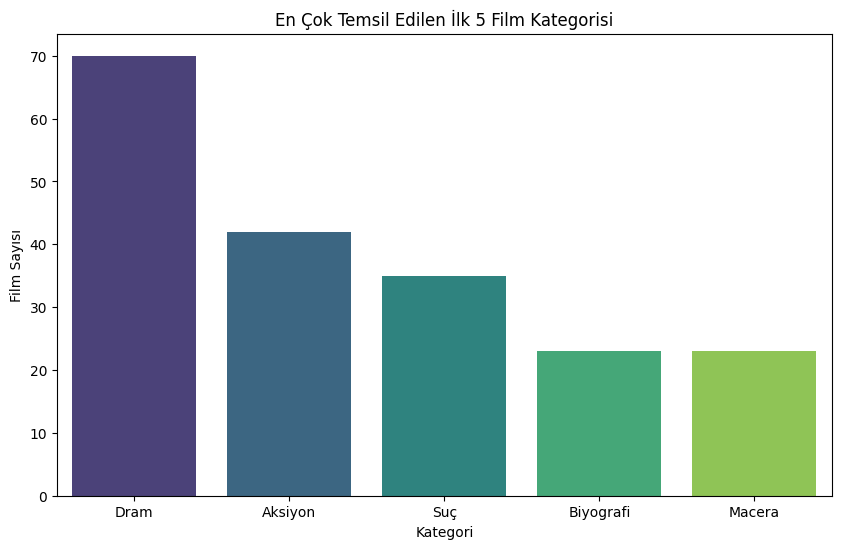

In [5]:
#  En Çok Tekrar Eden 5 Ana Kategori
plt.figure(figsize=(10, 6))
top_categories = df['Ana_Kategori'].value_counts().head(5)
sns.barplot(x=top_categories.index, y=top_categories.values, palette="viridis")
plt.title('En Çok Temsil Edilen İlk 5 Film Kategorisi')
plt.ylabel('Film Sayısı')
plt.xlabel('Kategori')
plt.show()

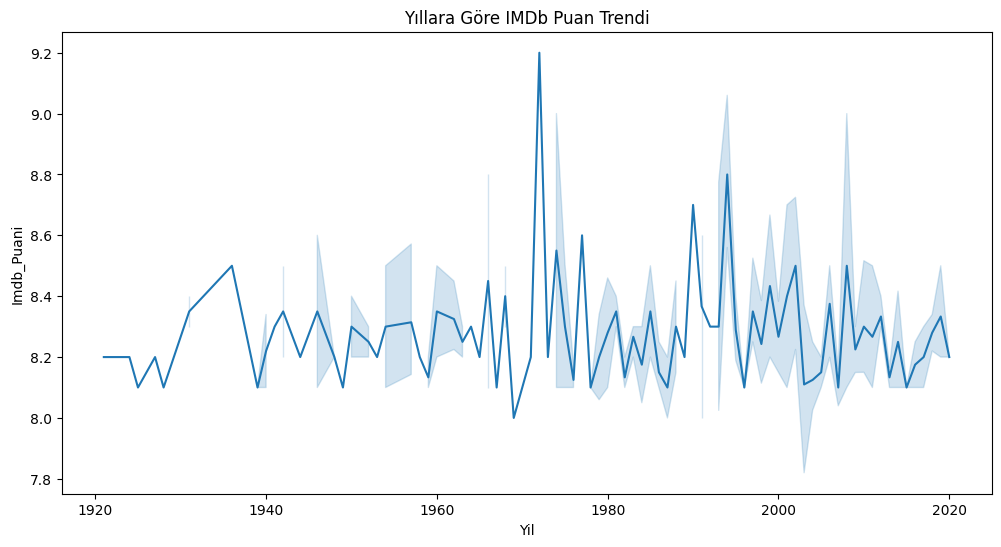

In [6]:
# Yıllara Göre IMDb Puan Değişimi
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Yil', y='Imdb_Puani')
plt.title('Yıllara Göre IMDb Puan Trendi')
plt.show()

In [7]:

# istatiksel özet
print("\n EDA İçgörüleri ")
print(f"En çok film içeren kategori: {df['Ana_Kategori'].mode()[0]}") 
print(f"Filmlerin ortalama yaşı: {df['Film_Yasi'].mean():.1f}")


 EDA İçgörüleri 
En çok film içeren kategori: Dram
Filmlerin ortalama yaşı: 39.5


In [8]:
import random

def film_oner_kategoriye_gore():
    conn = sqlite3.connect('movie.db')
    cursor = conn.cursor()
    
    print("Mevcut Kategoriler: Dram, Suç, Aksiyon, Macera, Biyografi vb.")
    secilen_kategori = input("Hangi kategoride film istersin? ").strip()

    # 'LIKE' kullanarak içinde geçen kelimeye göre arama yapıyoruz (Örn: 'Suç-Dram' içinde 'Dram' aramak)
    sorgu = "SELECT * FROM ImdbTop250 WHERE Kategori LIKE ?"
    cursor.execute(sorgu, ('%' + secilen_kategori + '%',))
    filmler = cursor.fetchall()

    if not filmler:
        print(f"\nÜzgünüm, '{secilen_kategori}' kategorisinde bir film bulunamadı.")
        print("Lütfen yazım hatası yapmadığınızdan emin olun (Örn: Dram).")
    else:
        # Rastgele bir film seçiyoruz
        onerilen_film = random.choice(filmler)
        
        print("\n--- Sizin İçin Rastgele Film Önerisi ---")
        print(f" Film Adı: {onerilen_film[1]}")
        print(f" Kategori: {onerilen_film[2]}")
        print(f" IMDb Puanı: {onerilen_film[3]}")
        print(f" Yapım Yılı: {onerilen_film[4]}")
      

    conn.close()

film_oner_kategoriye_gore()

Mevcut Kategoriler: Dram, Suç, Aksiyon, Macera, Biyografi vb.

--- Sizin İçin Rastgele Film Önerisi ---
 Film Adı: Psycho
 Kategori: Korku-Gizem-Gerilim
 IMDb Puanı: 8.5
 Yapım Yılı: 1960


In [9]:
pip install scikit-learn pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


--- Model Başarı Raporu ---
              precision    recall  f1-score   support

           0       0.29      0.15      0.20        13
           1       0.74      0.86      0.80        37

    accuracy                           0.68        50
   macro avg       0.51      0.51      0.50        50
weighted avg       0.62      0.68      0.64        50



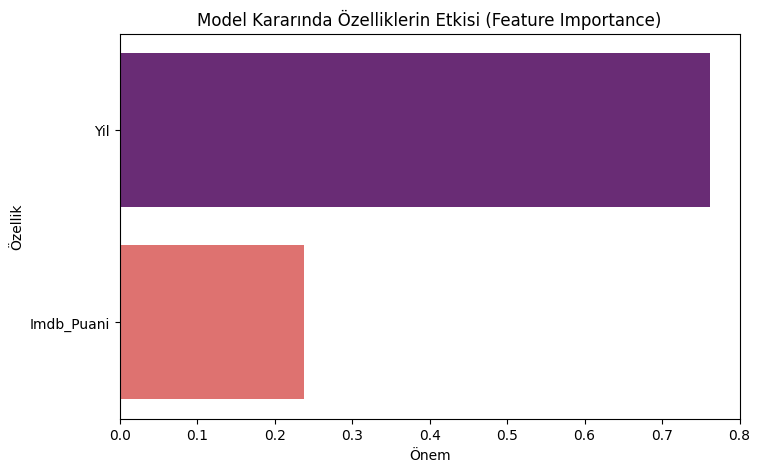

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. VERİ HAZIRLAMA 
conn = sqlite3.connect('movie.db')
df = pd.read_sql_query("SELECT * FROM ImdbTop250", conn)
conn.close()

# Hedef Değişken: Film 'Dram' içeriyor mu? (1 veya 0)
df['Is_Drama'] = df['Kategori'].apply(lambda x: 1 if 'Dram' in x else 0)

# Özellikler (X) ve Hedef (y) seçimi
X = df[['Yil', 'Imdb_Puani']]
y = df['Is_Drama']

# 2. MODELLEME 
# Veriyi Eğitim ve Test olarak ayırıyoruz (Train-Test Split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Modeli oluşturma 
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 3. DEĞERLENDİRME 
y_pred = model.predict(X_test)

print("--- Model Başarı Raporu ---")
print(classification_report(y_test, y_pred))

# 4. MODEL YORUMLANABİLİRLİĞİ: Özellik Önem Düzeyi 
importances = model.feature_importances_
feature_df = pd.DataFrame({'Özellik': X.columns, 'Önem': importances})

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_df, x='Önem', y='Özellik', palette='magma', hue='Özellik', legend=False)
plt.title('Model Kararında Özelliklerin Etkisi (Feature Importance)')
plt.show()